# Plant Disease Classification — CNN Training Pipeline
Trains a CNN on the PlantVillage dataset (downloaded from Kaggle), evaluates it, visualizes results (training curves, confusion matrix, Grad-CAM), and saves the trained model to disk.

## Section 1: Dependencies

In [2]:
!pip install torch torchvision matplotlib plotly torchviz opencv-python pytorch-gradcam grad-cam

In [3]:
import os
import shutil
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from torch.optim.lr_scheduler import ReduceLROnPlateau
import logging
import cv2

# Set up logging
logging.basicConfig(filename='training_log.txt', level=logging.INFO,
                   format='%(asctime)s - %(message)s')

## Section 2: Kaggle Dataset Download

In [4]:
def setup_kaggle_credentials():
    """
    Configures Kaggle API credentials from a kaggle.json file.

    - If running in Google Colab, this pops up a file-upload widget so you
      can upload kaggle.json directly.
    - Otherwise, it looks for kaggle.json in the current working directory.
    """
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    dest_path = kaggle_dir / 'kaggle.json'

    if dest_path.exists():
        print(f"Kaggle credentials already configured at {dest_path}")
        os.chmod(dest_path, 0o600)
        return

    try:
        from google.colab import files  # only exists inside Colab
        print("Please upload your kaggle.json file...")
        uploaded = files.upload()
        if 'kaggle.json' not in uploaded:
            raise FileNotFoundError(
                "Uploaded file must be named 'kaggle.json'. Got: "
                f"{list(uploaded.keys())}"
            )
        shutil.move('kaggle.json', dest_path)
    except ImportError:
        # Not running in Colab — expect kaggle.json next to this script
        local_path = Path('kaggle.json')
        if not local_path.exists():
            raise FileNotFoundError(
                "kaggle.json not found. Download it from Kaggle "
                "(Account -> API -> Create New Token) and place it in this "
                "script's working directory, then re-run."
            )
        shutil.copy(local_path, dest_path)

    os.chmod(dest_path, 0o600)
    print(f"Kaggle credentials configured at {dest_path}")

In [5]:
def download_plantvillage_dataset(dataset_slug='emmarex/plantdisease',
                                   download_dir='./data'):
    """
    Downloads and extracts the PlantVillage dataset via the Kaggle API.
    Skips the download if the data already exists locally.

    Returns the path to the folder that contains the per-class subfolders
    (e.g. .../data/PlantVillage/Tomato_Bacterial_spot/).
    """
    download_dir = Path(download_dir)
    download_dir.mkdir(parents=True, exist_ok=True)

    expected_root = download_dir / 'PlantVillage'
    if expected_root.exists() and any(expected_root.iterdir()):
        print(f"Dataset already present at {expected_root}, skipping download.")
        return str(expected_root)

    try:
        import kaggle  # noqa: F401
    except ImportError:
        import subprocess
        print("Installing the kaggle package...")
        subprocess.run(['pip', 'install', '-q', 'kaggle'], check=True)

    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()

    print(f"Downloading dataset '{dataset_slug}' (this can take a few minutes)...")
    api.dataset_download_files(dataset_slug, path=str(download_dir), unzip=True)

    if not expected_root.exists():
        # Some Kaggle datasets unzip with a different top-level folder name —
        # fall back to whatever single folder was created.
        subfolders = [p for p in download_dir.iterdir() if p.is_dir()]
        if len(subfolders) == 1:
            expected_root = subfolders[0]
        else:
            raise FileNotFoundError(
                f"Could not locate the extracted dataset folder under {download_dir}. "
                f"Found: {[p.name for p in subfolders]}"
            )

    print(f"Dataset ready at {expected_root}")
    return str(expected_root)

## Section 3: Dataset

In [6]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.images = []
        self.labels = []

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_dir):
                self.images.append(os.path.join(class_dir, img_name))
                self.labels.append(self.class_to_idx[class_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            print(f"Warning: Skipping problematic image at {img_path}")
            return self.__getitem__((idx + 1) % len(self))

        if self.transform:
            image = self.transform(image)

        return image, label

## Section 4: Model Architecture

In [7]:
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=15):
        super(CNNClassifier, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )

        self.fc_layers = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

## Section 5: Model / Grad-CAM Visualization

In [8]:
def visualize_model(model, device):
    sample_input = torch.randn(1, 3, 128, 128).to(device)

    print("Model Architecture Visualization:")
    print("\nConvolutional Layers:")
    x = sample_input

    for i, layer in enumerate(model.conv_layers):
        x = layer(x)
        print(f"Layer {i}: {layer.__class__.__name__} -> Output shape: {x.shape}")

    print("\nFully Connected Layers:")
    x = x.view(x.size(0), -1)

    for i, layer in enumerate(model.fc_layers):
        x = layer(x)
        print(f"Layer {i}: {layer.__class__.__name__} -> Output shape: {x.shape}")

In [9]:
def visualize_grad_cam(model, image, label, device, class_names):
    model.eval()

    target_layer = model.conv_layers[-2]  # Choose the layer to visualize
    activations = None
    gradients = None

    def save_activation(module, input, output):
        nonlocal activations
        activations = output

    def save_gradient(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0]

    handle1 = target_layer.register_forward_hook(save_activation)
    handle2 = target_layer.register_backward_hook(save_gradient)

    output = model(image.unsqueeze(0).to(device))
    pred = output.argmax(dim=1).item()

    model.zero_grad()
    class_loss = output[0, pred]
    class_loss.backward()

    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
    for i in range(activations.shape[1]):
        activations[:, i, :, :] *= pooled_gradients[i]

    heatmap = torch.mean(activations, dim=1).squeeze()
    heatmap = torch.relu(heatmap)
    heatmap /= torch.max(heatmap)

    heatmap = heatmap.detach().cpu().numpy()
    heatmap = cv2.resize(heatmap, (128, 128))

    img = image.cpu().numpy().transpose(1, 2, 0)
    img = (img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]) * 255
    img = img.astype(np.uint8)

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    ax1.imshow(img)
    ax1.set_title('Original Image')
    ax1.axis('off')

    ax2.imshow(heatmap)
    ax2.set_title('Grad-CAM Heatmap')
    ax2.axis('off')

    ax3.imshow(superimposed_img)
    ax3.set_title('Superimposed')
    ax3.axis('off')

    plt.suptitle(f'True: {class_names[label.item()]}\nPredicted: {class_names[pred]}')
    plt.show()

    handle1.remove()
    handle2.remove()

## Section 6: Training Utilities (Early Stopping)

In [10]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, verbose=False):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

## Section 7: Metrics / Results Plotting

In [11]:
def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, lr_history):
    fig = make_subplots(rows=3, cols=1, subplot_titles=('Loss', 'Accuracy', 'Learning Rate'))

    fig.add_trace(go.Scatter(y=train_losses, name='Training Loss', line=dict(color='blue')), row=1, col=1)
    fig.add_trace(go.Scatter(y=val_losses, name='Validation Loss', line=dict(color='orange')), row=1, col=1)

    fig.add_trace(go.Scatter(y=train_accuracies, name='Training Accuracy', line=dict(color='blue')), row=2, col=1)
    fig.add_trace(go.Scatter(y=val_accuracies, name='Validation Accuracy', line=dict(color='orange')), row=2, col=1)

    fig.add_trace(go.Scatter(y=lr_history, name='Learning Rate', line=dict(color='green')), row=3, col=1)

    fig.update_layout(height=900, width=800, title_text='Training Metrics')
    fig.show()

In [12]:
def plot_confusion_matrix(confusion_matrix, class_names):
    plt.figure(figsize=(12, 10))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Section 8: Evaluation Loop

In [13]:
def evaluate_model(model, test_loader, criterion, device, class_names):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy = 100 * correct / total
    conf_matrix = confusion_matrix(all_labels, all_preds)
    classification_rep = classification_report(all_labels, all_preds, target_names=class_names)

    return test_loss, test_accuracy, classification_rep, conf_matrix

## Section 9: Training Loop

In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    early_stopping = EarlyStopping(patience=7, verbose=True)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_val_accuracy = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_epoch_loss = val_loss / len(val_loader)
        val_epoch_acc = 100 * correct / total
        val_losses.append(val_epoch_loss)
        val_accuracies.append(val_epoch_acc)

        scheduler.step(val_epoch_loss)

        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%')
        print(f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.2f}%')
        print('--------------------')

        logging.info(f'Epoch {epoch+1}, Train Loss: {epoch_loss:.4f}, '
                    f'Train Acc: {epoch_acc:.2f}%, Val Loss: {val_epoch_loss:.4f}, '
                    f'Val Acc: {val_epoch_acc:.2f}%')

        # --- Model checkpointing: saves whenever validation accuracy improves ---
        if val_epoch_acc > best_val_accuracy:
            best_val_accuracy = val_epoch_acc
            torch.save(model.state_dict(), 'best_model.pth')

        early_stopping(val_epoch_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

    return train_losses, val_losses, train_accuracies, val_accuracies

## Section 10: Inference (Load Saved Model + Predict)

In [15]:
def predict_disease(image_path, model_path, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    model = CNNClassifier(num_classes=len(class_names)).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        predicted_prob, predicted_idx = torch.max(probabilities, 1)

    predicted_class = class_names[predicted_idx.item()]
    confidence = predicted_prob.item() * 100

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Predicted Disease: {predicted_class}\nConfidence: {confidence:.2f}%')
    plt.show()

    top_probs, top_indices = torch.topk(probabilities, 3)
    print("\nTop 3 Predictions:")
    for i in range(3):
        print(f"{class_names[top_indices[0][i]]}: {top_probs[0][i]*100:.2f}%")

    return predicted_class, confidence

## Section 11: Main Pipeline
Run the cells below in order. This is the notebook equivalent of `main()` from the script version, split into separate cells so you can inspect outputs (plots, metrics) at each stage.

### 11.1 — Reproducibility + device setup

In [16]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 11.2 — Get the dataset (uploads kaggle.json the first time it's needed)

In [17]:
setup_kaggle_credentials()
root_dir = download_plantvillage_dataset(
    dataset_slug='emmarex/plantdisease',
    download_dir='./data'
)

Please upload your kaggle.json file...


Saving kaggle.json to kaggle.json
Kaggle credentials configured at /root/.kaggle/kaggle.json
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
Dataset ready at data/PlantVillage


### 11.3 — Data transforms + dataset/loader construction

In [18]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

dataset = CustomImageDataset(root_dir=root_dir, transform=train_transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

### 11.4 — Model, loss, optimizer

In [19]:
num_classes = len(dataset.classes)
model = CNNClassifier(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

visualize_model(model, device)

Model Architecture Visualization:

Convolutional Layers:
Layer 0: Conv2d -> Output shape: torch.Size([1, 32, 128, 128])
Layer 1: ReLU -> Output shape: torch.Size([1, 32, 128, 128])
Layer 2: BatchNorm2d -> Output shape: torch.Size([1, 32, 128, 128])
Layer 3: MaxPool2d -> Output shape: torch.Size([1, 32, 64, 64])
Layer 4: Conv2d -> Output shape: torch.Size([1, 64, 64, 64])
Layer 5: ReLU -> Output shape: torch.Size([1, 64, 64, 64])
Layer 6: BatchNorm2d -> Output shape: torch.Size([1, 64, 64, 64])
Layer 7: MaxPool2d -> Output shape: torch.Size([1, 64, 32, 32])
Layer 8: Conv2d -> Output shape: torch.Size([1, 128, 32, 32])
Layer 9: ReLU -> Output shape: torch.Size([1, 128, 32, 32])
Layer 10: BatchNorm2d -> Output shape: torch.Size([1, 128, 32, 32])
Layer 11: MaxPool2d -> Output shape: torch.Size([1, 128, 16, 16])
Layer 12: Conv2d -> Output shape: torch.Size([1, 256, 16, 16])
Layer 13: ReLU -> Output shape: torch.Size([1, 256, 16, 16])
Layer 14: BatchNorm2d -> Output shape: torch.Size([1, 256

### 11.5 — Train

In [20]:
num_epochs = 50
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, device
)

plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, [])

Epoch [1/50]
Train Loss: 1.4511, Train Acc: 56.62%
Val Loss: 0.9078, Val Acc: 71.95%
--------------------
Epoch [2/50]
Train Loss: 0.9528, Train Acc: 70.19%
Val Loss: 0.5515, Val Acc: 82.58%
--------------------
Epoch [3/50]
Train Loss: 0.8037, Train Acc: 75.10%
Val Loss: 0.5146, Val Acc: 83.33%
--------------------
Epoch [4/50]
Train Loss: 0.6577, Train Acc: 79.26%
Val Loss: 0.4955, Val Acc: 85.07%
--------------------
Epoch [5/50]
Train Loss: 0.5879, Train Acc: 82.16%
Val Loss: 0.3396, Val Acc: 90.69%
--------------------
Epoch [6/50]
Train Loss: 0.4900, Train Acc: 84.86%
Val Loss: 0.3169, Val Acc: 90.63%
--------------------
Epoch [7/50]
Train Loss: 0.4410, Train Acc: 86.32%
Val Loss: 0.3453, Val Acc: 89.14%
--------------------
EarlyStopping counter: 1 out of 7
Epoch [8/50]
Train Loss: 0.4051, Train Acc: 88.00%
Val Loss: 0.2626, Val Acc: 91.79%
--------------------
Epoch [9/50]
Train Loss: 0.3682, Train Acc: 88.78%
Val Loss: 0.2426, Val Acc: 93.38%
--------------------
Epoch [10/50

### 11.6 — Evaluate on test set


Test Results:
Test Loss: 0.0253
Test Accuracy: 99.35%

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.99      0.99       155
                     Pepper__bell___healthy       1.00      0.99      0.99       215
                      Potato___Early_blight       1.00      1.00      1.00       152
                       Potato___Late_blight       0.96      1.00      0.98       147
                           Potato___healthy       1.00      0.92      0.96        24
                      Tomato_Bacterial_spot       0.99      0.99      0.99       336
                        Tomato_Early_blight       0.99      0.99      0.99       144
                         Tomato_Late_blight       0.99      0.99      0.99       269
                           Tomato_Leaf_Mold       0.99      0.99      0.99       151
                  Tomato_Septoria_leaf_spot       1.00      0.99      

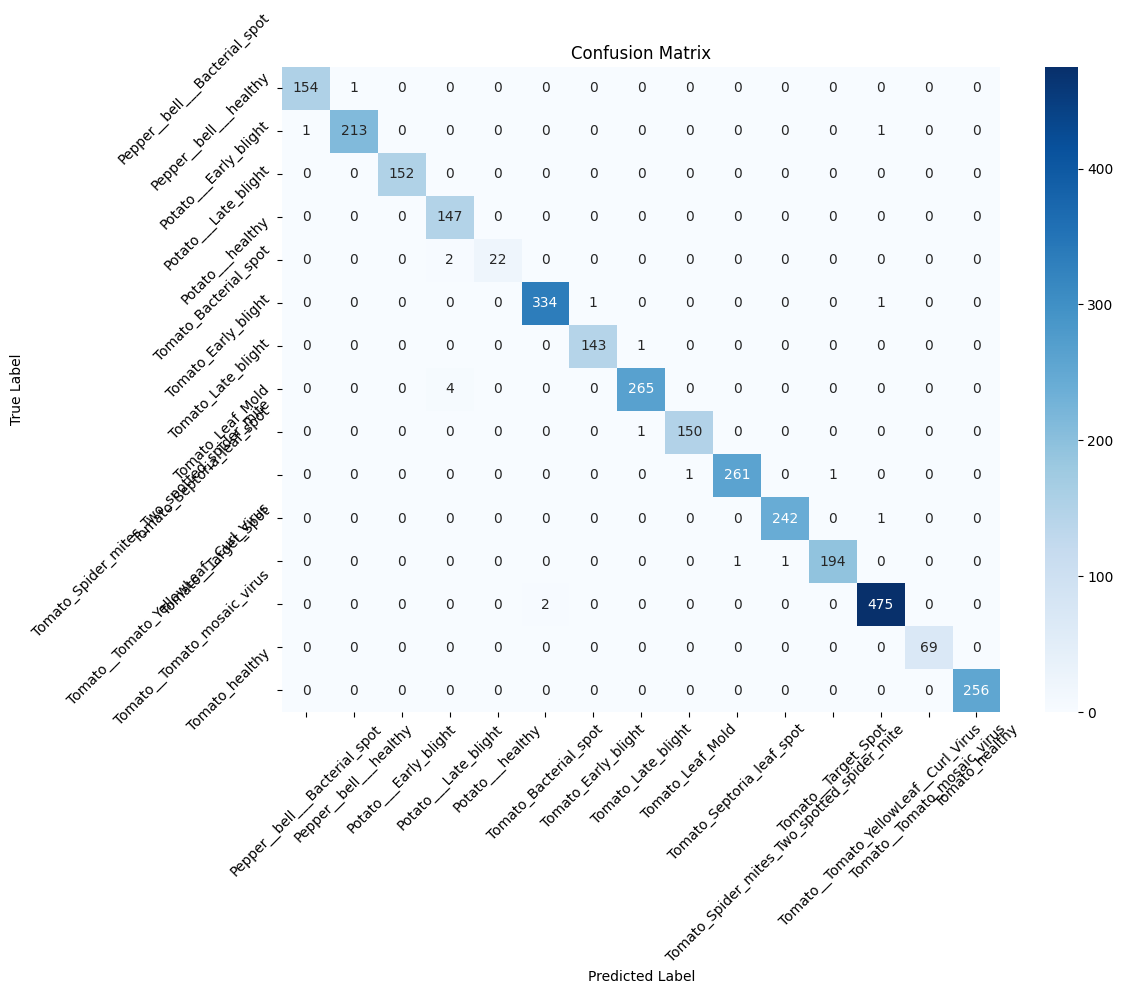

In [21]:
test_loss, test_accuracy, classification_rep, conf_matrix = evaluate_model(
    model, test_loader, criterion, device, dataset.classes
)

print("\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print("\nClassification Report:")
print(classification_rep)

plot_confusion_matrix(conf_matrix, dataset.classes)

### 11.7 — Save final model

In [25]:
torch.save(model.state_dict(), 'final_model.pth')
print("\nTraining completed. Model saved as 'final_model.pth'")


Training completed. Model saved as 'final_model.pth'


### 11.8 — Sample prediction + Grad-CAM on one image from the dataset

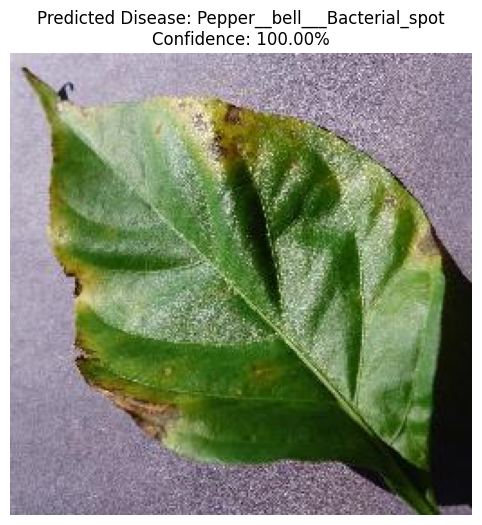


Top 3 Predictions:
Pepper__bell___Bacterial_spot: 100.00%
Pepper__bell___healthy: 0.00%
Tomato_Early_blight: 0.00%


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning:

Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.



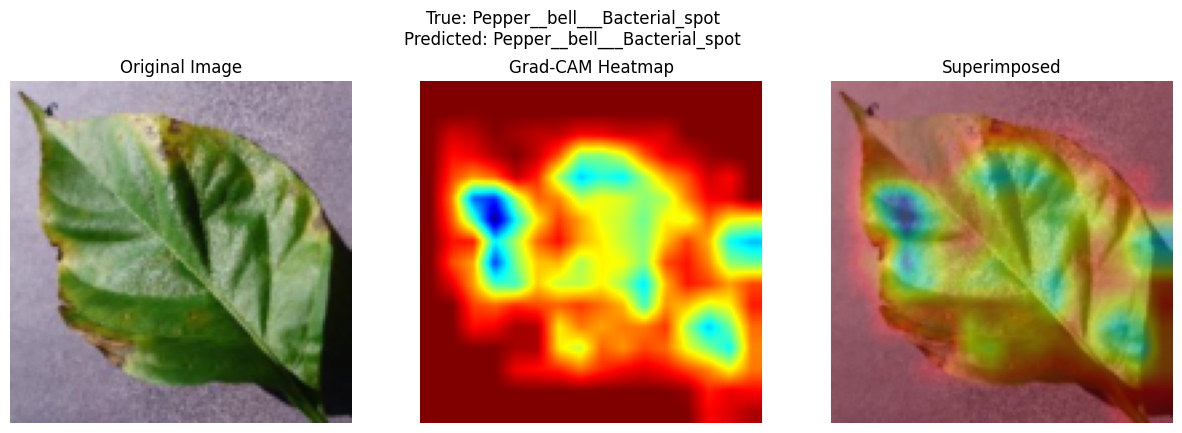

In [23]:
sample_image_path = dataset.images[0]
predicted_class, confidence = predict_disease(sample_image_path, 'final_model.pth', dataset.classes)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

image = Image.open(sample_image_path).convert('RGB')
image_tensor = transform(image).unsqueeze(0)

visualize_grad_cam(model, image_tensor.squeeze(0), torch.tensor(dataset.class_to_idx[predicted_class]), device, dataset.classes)